In [ ]:
#Data Loading
import pandas as pd

df = pd.read_csv("Invistico_Airline.csv")

#Displaying the first and last row of the dataset
print(f"The first row in the dataset is: {df.head(1)}")
print(f"The last row in the dataset is: {df.tail(1)}")

#Checking the number of rows and columns in the dataset
print(f"The number of rows and columns in the dataset is: {df.shape}")

#Identifying column names
print(f"The column names in the dataset are: {df.columns.tolist()}")

#Checking data types
print(f"The data types of each column in the dataset are: {df.dtypes}")

#Identifying any missing values in the dataset
print(f"The number of missing values in each column is: :\n{df.isnull().sum()}")

#Identifying any duplicate values in the dataset
print(f"The number of duplicate values in the dataset is: {df.duplicated().sum()}")

#Describing the dataset statistically
print(f"The statistical description of the dataset is:\n{df.describe()}")

In [ ]:
#Data Cleaning
import pandas as pd
df = pd.read_csv("Invistico_Airline.csv")
#Removing duplicate values to ensure there is no bias in the analysis
df = df.drop_duplicates()

#Renaming the columns to ensure consistency and avoid any errors during analysis
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

#Creating a new column to calculate the total delay caused for each flight
df['total_delay'] = df['departure_delay_in_minutes'] + df['arrival_delay_in_minutes']

#To ensure incomplete records do not affect the accuracy of the analysis.
#check for missing values
df = df.dropna()

#check for outliers
df[['age', 'flight_distance', 'departure_delay_in_minutes',
    'arrival_delay_in_minutes', 'total_delay']].describe()

#saving the cleaned dataset to a new CSV file for future analysis
df.to_csv("Cleaned_Invistico_Airline.csv", index=False)

#view the cleaned data
df.head()
# Check for remaining missing values
df.isnull().sum()

# Confirm the new column exists
df.columns.tolist()


## Exploratory Data Analysis

This section answers 8 key questions about customer satisfaction, delays, and service quality using the cleaned dataset.

In [ ]:
#Data analysis
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("Cleaned_Invistico_Airline.csv")

**Q1: What is the overall distribution of customer satisfaction?**

Out of 129,487 customers, 70,882 (about 55%) were satisfied and 58,605 (about 45%) were dissatisfied.

In [ ]:
#Count customer satisfaction levels
analysis = df['satisfaction'].value_counts()
display(analysis)

**Q2: How many customers were satisfied and travelled in Business Class?**

43,977 customers were both satisfied and flew Business Class — the largest satisfied group among the three travel classes.

In [1]:
#How many customers were satisfied and travelled in Business Class?
business_satisfied = df[
    (df['class'] == 'Business') &
    (df['satisfaction'] == 'satisfied')
]
business_satisfied.head()
len(business_satisfied)

NameError: name 'df' is not defined

**Q3: Which flights experienced the highest total delays?**

The most delayed flight had of 3,176 minutes (around 53 hours). However, the top 10 most delayed flights still had a higher average satisfied number of customers compared to flights that experienced the least delays.

In [ ]:
#Which flights experienced the highest total delays?
analysis = df.sort_values(by='total_delay', ascending=False)[
    ['flight_distance', 'total_delay', 'satisfaction']
].head(10)
display(analysis)

**Q4: What is the average total delay for each travel class?**

Eco Plus passengers had the highest average delay (~30.8 min), Eco was close behind (~30.6 min), and Business class had the lowest (~28.7 min). This could be due to the order in which the different travel classes are arranged to board the plane since the difference between Eco and Eco Plus is very small while Business class has a shorter delay.

In [ ]:
#What is the average total delay for each travel class?
analysis = df.groupby('class')['total_delay'].mean()
display(analysis)

**Q5: What are the average, maximum, and minimum delays for satisfied vs. dissatisfied customers?**

Dissatisfied customers had a noticeably higher average delay (~36.2 min) than satisfied customers (~24.4 min), suggesting longer delays are associated with lower satisfaction. However, both groups include flights with 0 delay and flights with very extreme delays.

In [ ]:
#Average, maximum, and minimum delays
analysis = df.groupby('satisfaction')['total_delay'].agg(['mean', 'max', 'min'])
display(analysis)

**Q6: How many customers travelled in each class?**

Business class had the most customers (61,990), followed by Eco (58,117) and Eco Plus (9,380). Showing that Business class sells the most seats 

In [ ]:
#Customer in each travel class
analysis = df['class'].value_counts()
display(analysis)

**Q7: What is the average age of satisfied vs. dissatisfied customers?**

Satisfied customers were slightly older on average (~41.0 years) than dissatisfied customers (~37.5 years).

In [ ]:
#Average age of satisfied and dissatisfied customers
analysis = df.groupby('satisfaction')['age'].mean()
display(analysis)

**Q8: Which services receive the highest average ratings?**

Cleanliness (3.71) and baggage handling (3.70) received the highest average ratings, while seat comfort (2.84) and food and drink (2.85) received the lowest. This suggests the onboard comfort experience has more room for improvement than staff-driven services.

In [ ]:
#Which services receive the highest average ratings?
service_ratings = [
    'inflight_wifi_service',
    'departure/arrival_time_convenient',
    'ease_of_online_booking',
    'gate_location',
    'food_and_drink',
    'online_boarding',
    'seat_comfort',
    'inflight_entertainment',
    'on-board_service',
    'leg_room_service',
    'baggage_handling',
    'checkin_service',
    'cleanliness'
]

analysis = df[service_ratings].mean().sort_values(ascending=False)
display(analysis)

**Summary statistics for key numeric columns**

The typical passenger is about 39 years old and flies roughly 1,981 miles. The median total delay is only 2 minutes, but the distribution is heavily skewed by a small number of very long delays (max 3,176 minutes). Most flights are on time, and a few extreme delays pull the average up.

In [ ]:
#summary statistics
analysis = df[['age','flight_distance', 'total_delay']].describe()
display(analysis)

In [ ]:
#Data analysis
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("Cleaned_Invistico_Airline.csv")   

#Count customer satisfaction levels
analysis = df['satisfaction'].value_counts()
display(analysis)

#How many customers were satisfied and travelled in Business Class?
business_satisfied = df[
    (df['class'] == 'Business') &
    (df['satisfaction'] == 'satisfied')
]
business_satisfied.head()
len(business_satisfied)


#Which flights experienced the highest total delays?
analysis = df.sort_values(by='total_delay', ascending=False)[
    ['flight_distance', 'total_delay', 'satisfaction']
].head(10)
display(analysis)

#What is the average total delay for each travel class?
analysis = df.groupby('class')['total_delay'].mean()
display(analysis)

#Average, maximum, and minimum delays
analysis = df.groupby('satisfaction')['total_delay'].agg(['mean', 'max', 'min'])
display(analysis)

#Customer in each travel class
analysis = df['class'].value_counts()
display(analysis)

#Average age of satisfied and dissatisfied customers
analysis = df.groupby('satisfaction')['age'].mean()
display(analysis)

#Which services receive the highest average ratings?
service_ratings = [
    'inflight_wifi_service',
    'departure/arrival_time_convenient',
    'ease_of_online_booking',
    'gate_location',
    'food_and_drink',
    'online_boarding',
    'seat_comfort',
    'inflight_entertainment',
    'on-board_service',
    'leg_room_service',
    'baggage_handling',
    'checkin_service',
    'cleanliness'
]

analysis = df[service_ratings].mean().sort_values(ascending=False)
display(analysis)

#summary statistics
analysis = df[['age','flight_distance', 'total_delay']].describe()
display(analysis)

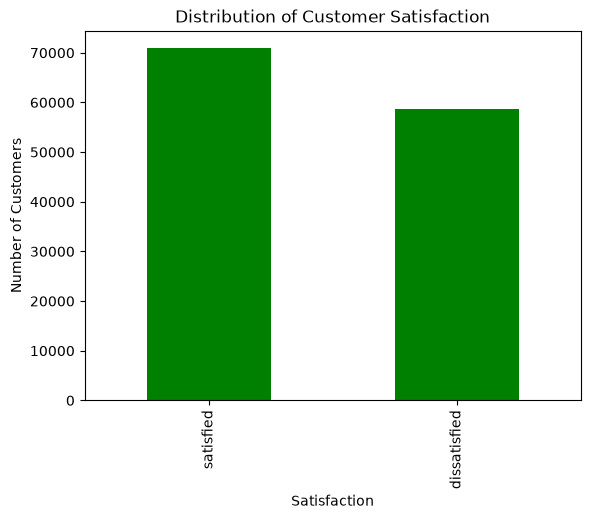

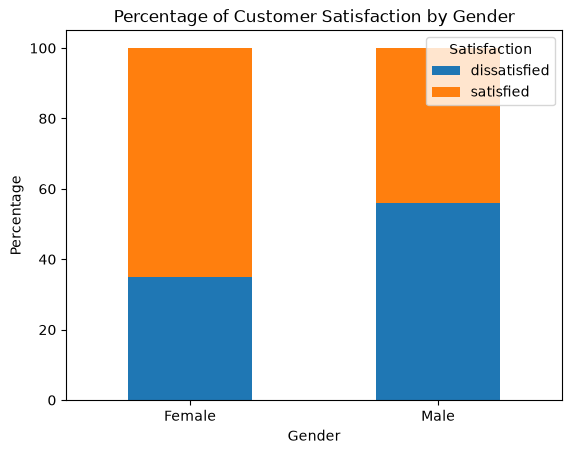

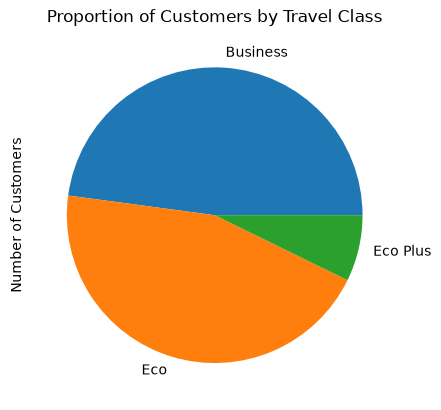

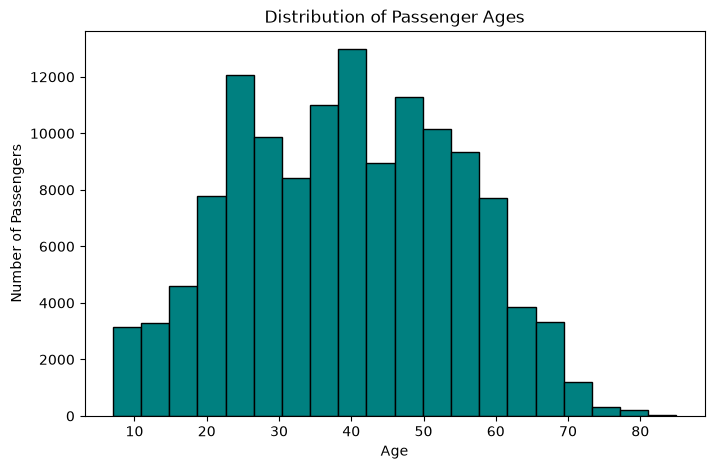

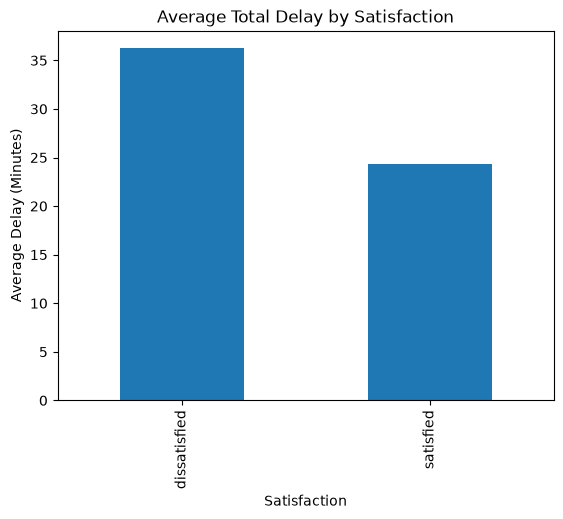

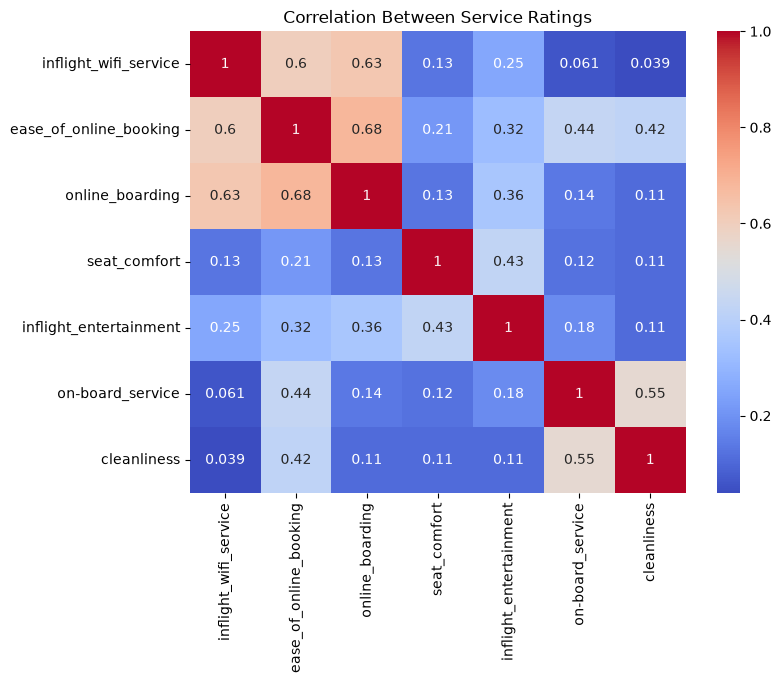

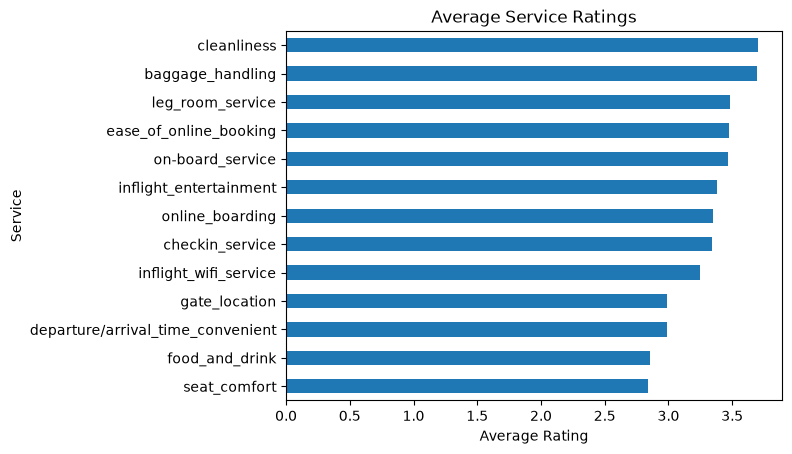

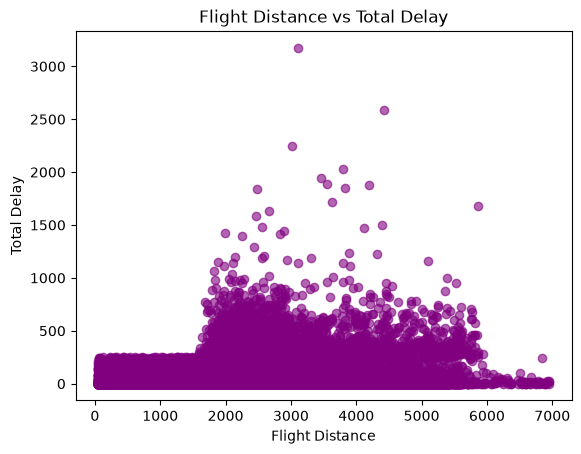

In [10]:
#Data Visualisation
#Distribution of customer satisfaction
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("Cleaned_Invistico_Airline.csv")

#Count customer satisfaction levels
analysis = df['satisfaction'].value_counts()
import matplotlib.pyplot as plt
df['satisfaction'].value_counts().plot(kind='bar', color="green")
plt.title("Distribution of Customer Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Number of Customers")
plt.show()


#Does gender influence customer satisfaction?
(pd.crosstab(df['gender'], df['satisfaction'], normalize='index') * 100).plot(
    kind='bar',
    stacked=True
)
plt.title("Percentage of Customer Satisfaction by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")
plt.show()



#Proportion of customers travelled in each class
analysis = df['class'].value_counts()
df['class'].value_counts().plot(kind='pie')
plt.title("Proportion of Customers by Travel Class")
plt.ylabel("Number of Customers")
plt.show()

#Passenger age
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20, color='teal',
    edgecolor='black')
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

#How does total delay affect customer satisfaction?
analysis = df.groupby('satisfaction')['total_delay'].mean()
df.groupby('satisfaction')['total_delay'].mean().plot(kind='bar')
plt.title("Average Total Delay by Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Average Delay (Minutes)")
plt.show()

#How are the service ratings correlated?
import seaborn as sns
service_columns = [
    'inflight_wifi_service',
    'ease_of_online_booking',
    'online_boarding',
    'seat_comfort',
    'inflight_entertainment',
    'on-board_service',
    'cleanliness'
]
corr = df[service_columns].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Service Ratings")
plt.show()

#Which services receive the highest average ratings?
service_ratings = [
    'inflight_wifi_service',
    'departure/arrival_time_convenient',
    'ease_of_online_booking',
    'gate_location',
    'food_and_drink',
    'online_boarding',
    'seat_comfort',
    'inflight_entertainment',
    'on-board_service',
    'leg_room_service',
    'baggage_handling',
    'checkin_service',
    'cleanliness'
]

analysis = df[service_ratings].mean().sort_values(ascending=False)
df[service_ratings].mean().sort_values().plot(kind='barh')
plt.title("Average Service Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Service")
plt.show()

#Is there a relationship between flight distance and total delay?
plt.scatter(df['flight_distance'], df['total_delay'],  color='purple',
    alpha=0.6)
plt.title("Flight Distance vs Total Delay")
plt.xlabel("Flight Distance")
plt.ylabel("Total Delay")
plt.show()
